In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from plots import *
import seaborn as sns

from string import ascii_lowercase
from statsmodels.stats.multitest import multipletests

In [2]:
data_fpath = Path('stable_scores.csv')
df = pd.read_csv(data_fpath)

df_ps_cols = pd.read_csv('df_ps_col_labels.csv')
ps_cols = df_ps_cols['ps'].values
ps_cols_labels = dict(zip(df_ps_cols['ps'], df_ps_cols['label']))

figdir = Path('figs')
figdir.mkdir(parents=True, exist_ok=True)


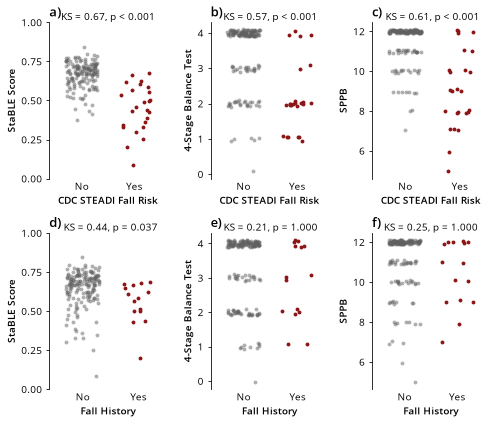

[KstestResult(statistic=np.float64(0.6748387096774193), pvalue=np.float64(4.913683412411285e-10), statistic_location=np.float64(0.6233262881921909), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.5664516129032258), pvalue=np.float64(5.535128044624117e-07), statistic_location=np.int64(2), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.6051612903225806), pvalue=np.float64(5.45694813277841e-08), statistic_location=np.int64(10), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.44242424242424244), pvalue=np.float64(0.006182419711673346), statistic_location=np.float64(0.6867984731970436), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.21212121212121213), pvalue=np.float64(0.5126151506675004), statistic_location=np.int64(3), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.24848484848484848), pvalue=np.float64(0.3197847248363629), statistic_location=np.int64(10), statistic_sign=np.int8(-1))]

In [3]:
rng = np.random.default_rng(0)


def plot_ks_scatter(xvar, xname, yvar, yname, xjit=0.2, yjit=0, yticks=None):
    xx = df[xvar].values
    yy = df[yvar].values
    xjit = rng.uniform(-1, 1, xx.size) * xjit
    yjit = rng.uniform(-1, 1, xx.size) * yjit
    plt.scatter(xx[xx==0]+xjit[xx==0], yy[xx==0]+yjit[xx==0], s=15, lw=0, c='#606060', alpha=0.5)
    plt.scatter(xx[xx==1]+xjit[xx==1], yy[xx==1]+yjit[xx==1], s=15, lw=0, c=cp[0])
    plt.xticks([0, 1], ['No', 'Yes'])
    sns.despine(bottom=True)
    plt.yticks(yticks)
    plt.gca().tick_params('x', length=0)
    plt.gca().set_xmargin(0.2)
    plt.xlabel(xname, fontdict={'weight':'semibold'})
    plt.ylabel(yname, fontdict={'weight':'semibold'})
    res = stats.ks_2samp(yy[xx==0], yy[xx==1], alternative='two-sided', method='exact')
    return res

balance_measures = [
    {
        'name': 'StaBLE Score',
        'var': 'stable_score',
        'yticks': [0, 0.25, 0.5, 0.75, 1],
        'yjit': 0.0
    },
    {
        'name': '4-Stage Balance Test',
        'var': 'four_stage_bt',
        'yticks': [0, 1, 2, 3, 4],
        'yjit': 0.1
    },
    {
        'name': 'SPPB',
        'var': 'sppb',
        'yticks': [6, 8, 10, 12],
        'yjit': 0.1
    },
]

fall_measures = [
    {
        'name': 'CDC STEADI Fall Risk',
        'var': 'cdc_fall_risk',
    },
    {
        'name': 'Fall History',
        'var': 'faller',
    },
]

plt.figure(figsize=(7,6))

all_res = []
nrows = len(fall_measures)
ncols = len(balance_measures)
for i, fall_measure in enumerate(fall_measures):
    for j, balance_measure in enumerate(balance_measures):
        plt.subplot(nrows, ncols, ncols*i + j + 1)
        subfig_letter = ascii_lowercase[ncols*i+j]
        res = plot_ks_scatter(
            xvar = fall_measure['var'],
            xname = fall_measure['name'],
            yvar = balance_measure['var'],
            yname = balance_measure['name'],
            xjit = 0.3, yjit = balance_measure['yjit'],
            yticks = balance_measure['yticks'])
        all_res.append(res)

ks_stats = [res.statistic for res in all_res]
pvalues = [res.pvalue for res in all_res]
_, pvals_adj, _, _ = multipletests(
    pvals=pvalues,
    method='bonferroni',
)
for i, fall_measure in enumerate(fall_measures):
    for j, balance_measure in enumerate(balance_measures):
        k = ncols * i + j
        pval = pvals_adj[k]
        subfig_letter = 'abcdef'[k]
        plt.subplot(nrows, ncols, k+1)
        plt.title(f'{subfig_letter})', loc='left', fontdict={'weight':'semibold', 'size':13})
        plt.text(0.5, plt.ylim()[1], f'KS = {ks_stats[k]:0.2f}, {pval_printer(pval)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(figdir / 'fig5.pdf', transparent=True)
plt.show()

all_res


In [4]:
print(f'{sum(df.cdc_fall_risk)} participants identifed as fall-risk (CDC Stay-Independent 12-question tool score = >=4)')
print(f'{sum(df.faller)} participants with a history falls (>=2 self-reported falls in the past year, non-athletes)')

25 participants identifed as fall-risk (CDC Stay-Independent 12-question tool score = >=4)
15 participants with a history falls (>=2 self-reported falls in the past year, non-athletes)


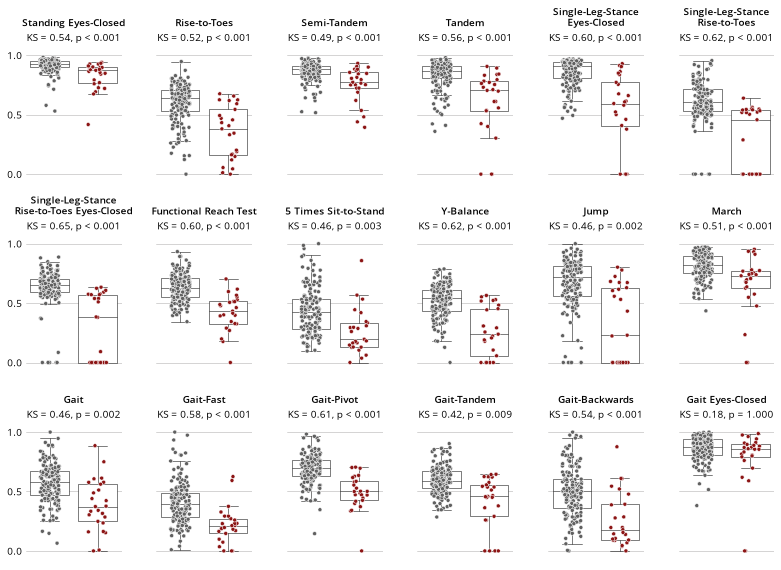

In [5]:
df_ps = pd.read_csv('df_ps_col_labels.csv')
scores = df_ps['ps'].values

df_ps['label'] = (df_ps['label']
                  .astype(str)
                  .str.replace('\r\n', '\n', regex=False)
                  .str.replace('\r', '\n', regex=False))
names = df_ps['label'].values

ks_all = []
pval_all = []
plt.figure(figsize=(11,8))
for i, (score, name) in enumerate(zip(scores, names)):
    plt.subplot(3,6,i+1)

    xvar, xlabel = 'cdc_fall_risk', 'CDC STEADI Fall Risk'
    yvar, ylabel = score, name

    sns.stripplot(df, x=xvar, y=yvar, jitter=0.2, size=4, linewidth=0.5, hue=xvar, palette=('#606060', cp[0]), edgecolor='white')
    sns.boxplot(df, x=xvar, y=yvar, fliersize=0, color='#ffffff', linecolor='k', linewidth=0.5)

    # stats
    res = stats.ks_2samp(df[yvar][df[xvar]==0], df[yvar][df[xvar]==1])
    ks_all.append(res.statistic)
    pval_all.append(res.pvalue)

    plt.axhline(0, c=cp[-1], alpha=0.5, lw=0.5, zorder=-1)
    plt.axhline(0.5, c=cp[-1], alpha=0.5, lw=0.5,  zorder=-1)
    plt.axhline(1, c=cp[-1], alpha=0.5, lw=0.5, zorder=-1)

    plt.ylabel(None)
    plt.xlabel(None)
    plt.ylim(-0.1, 1.1)
    if i % 6 > 0:
        plt.yticks([])
    else:
        plt.yticks([0, 0.5, 1])
        # sns.despine(bottom=True, trim=True, ax=plt.gca())
    sns.despine(left=True, bottom=True)
    plt.gca().get_legend().remove()
    plt.gca().tick_params(length=0, axis='both')
    plt.xticks([])

_, pvals_adj, _, _ = multipletests(pvals=pval_all, method='bonferroni')

for i, (score, name) in enumerate(zip(scores, names)):
    plt.subplot(3,6,i+1)
    plt.text(0.5, plt.ylim()[1], f'KS = {ks_all[i]:0.2f}, {pval_printer(pvals_adj[i])}', ha='center', va='bottom')
    plt.text(0.5, plt.ylim()[1]+0.125, f'{name}', ha='center', va='bottom', fontdict={'weight':'semibold'})

    # if i % 6:
plt.tight_layout()
plt.savefig(figdir / 'fig_s1.pdf', transparent=True)
plt.show()

In [6]:
df_stats = pd.DataFrame({
    'stat': ks_all,
    'pval': pvals_adj,
    'score': scores,
    'name': names,
    })
df_stats.sort_values('stat', ascending=False)


,stat,pval,score,name
6,0.646452,6.724994e-08,ps_sls_rtt_ec,Single-Leg-Stance\nRise-to-Toes Eyes-Closed
5,0.623226,3.113445e-07,ps_sls_rtt,Single-Leg-Stance\nRise-to-Toes
9,0.615484,5.221403e-07,ps_y_balance,Y-Balance
14,0.605161,9.822507e-07,ps_gait_pivot,Gait-Pivot
4,0.602581,1.172651e-06,ps_sls_ec,Single-Leg-Stance\nEyes-Closed
7,0.600000,1.370269e-06,ps_frt,Functional Reach Test
13,0.575484,5.975444e-06,ps_gait_fast,Gait-Fast
3,0.561290,1.340842e-05,ps_tandem,Tandem
16,0.541935,3.878635e-05,ps_gait_bwd,Gait-Backwards
0,0.535484,5.466568e-05,ps_standing_ec,Standing Eyes-Closed
